# Entrenamiento y Optimización — Smoking Dataset

Pipeline de modelado: baseline, optimización de hiperparámetros y evaluación final.
Modelos: Regresión Logística, Random Forest, XGBoost.
Métrica principal: **F1-score**.

## Librerias

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix,precision_score, recall_score, ConfusionMatrixDisplay,
    RocCurveDisplay
)
%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 12
sns.set_theme(style="whitegrid")

PAL = {0: "#378ADD", 1: "#D85A30"}
SEED = 42

## 1. Carga del dataset procesado y split train/test

In [12]:
df = pd.read_csv("C:\\Users\\anshu\\Desktop\\TP2-Diplomatura\\data\\processed\\smoking_processed.csv")
df["smoking"] = df["smoking"].astype(int)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (49866, 15)


,gender,age,waist_cm,systolic,relaxation,triglyceride,hdl,hemoglobin,serum_creatinine,gtp,dental_caries,smoking,liver_score,lipid_ratio,gender_x_hemoglobin
0,0,-0.347134,3.38,4.75,3.04,3.42,3.04,0.51,0.00,1.13,0,0,2.67,1.125000,0.00
1,0,-0.347134,3.38,4.96,2.92,4.79,1.75,0.50,0.00,0.75,0,0,2.46,2.737143,0.00
2,1,0.893385,3.33,5.75,3.58,7.58,2.29,0.63,0.04,0.92,0,1,2.47,3.310044,0.63
3,1,-0.347134,3.67,4.17,2.50,10.58,1.88,0.59,0.04,0.75,0,0,2.62,5.627660,0.59
4,0,-0.347134,3.58,5.00,3.08,3.08,2.58,0.50,0.00,0.92,0,0,2.17,1.193798,0.00
5,1,-1.174147,3.54,5.33,3.17,8.29,2.00,0.67,0.04,1.38,0,0,3.26,4.145000,0.67
6,1,-0.347134,3.55,4.83,3.42,2.83,2.29,0.71,0.00,1.63,1,1,3.64,1.235808,0.71
7,1,0.066372,4.00,6.38,4.00,11.21,1.42,0.63,0.04,4.63,0,0,9.17,7.894366,0.63
8,0,0.479878,3.54,4.79,3.08,2.75,2.00,0.55,0.01,0.58,0,0,3.16,1.375000,0.00
9,1,0.066372,3.71,4.71,2.67,6.13,1.79,0.67,0.01,2.63,0,0,4.71,3.424581,0.67


In [13]:
X= df.drop(columns=['smoking'])

y = df["smoking"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Balance train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Balance test:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (39892, 14)  |  Test: (9974, 14)
Balance train:
smoking
0    0.634
1    0.366
Name: proportion, dtype: float64
Balance test:
smoking
0    0.634
1    0.366
Name: proportion, dtype: float64


## Funciones auxiliares

In [14]:
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    return {
        "Modelo": nombre,
        "F1_fumador": round(f1_score(y_te, y_pred, pos_label=1), 4),  # métrica objetivo
        "ROC-AUC": round(roc_auc_score(y_te, y_prob), 4),
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Precision_fumador": round(precision_score(y_te, y_pred, pos_label=1), 4),
        "Recall_fumador": round(recall_score(y_te, y_pred, pos_label=1), 4),
        "_modelo": modelo,
        "_y_pred": y_pred,
        "_y_prob": y_prob
    }

def mostrar_confusion(resultados, y_te):
    fig, axes = plt.subplots(1, len(resultados), figsize=(5 * len(resultados), 4))
    for ax, r in zip(axes, resultados):
        cm = confusion_matrix(y_te, r["_y_pred"])
        ConfusionMatrixDisplay(cm, display_labels=["No fuma", "Fuma"]).plot(ax=ax, colorbar=False)
        ax.set_title(r["Modelo"])
    plt.tight_layout()
    plt.show()

def mostrar_roc(resultados, y_te):
    fig, ax = plt.subplots(figsize=(7, 5))
    for r in resultados:
        RocCurveDisplay.from_predictions(y_te, r["_y_prob"], name=r["Modelo"], ax=ax)
    ax.set_title("Curvas ROC — comparación de modelos")
    plt.tight_layout()
    plt.show()

## 3. Parámetros por defecto

Entrenamos los 3 modelos sin optimización para tener una referencia inicial.
Usamos `class_weight="balanced"` en LR y RF para compensar el desbalance (63/37).

In [18]:
modelos_base = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ("Random Forest",       RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=SEED)),
    ("XGBoost",             XGBClassifier(n_estimators=100, 
                                          scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
                                          random_state=SEED, eval_metric="logloss", verbosity=0)),
]

In [24]:
resultados_base = []

for nombre, modelo in modelos_base:
    r = evaluar(nombre, modelo, X_train, y_train, X_test, y_test)
    resultados_base.append(r)


In [25]:
df_base = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados_base])
df_base.set_index("Modelo")


,F1_fumador,ROC-AUC,Accuracy,Precision_fumador,Recall_fumador
Modelo,,,,,
Logistic Regression,0.7035,0.8262,0.7111,0.5632,0.9370
Random Forest,0.7396,0.8770,0.7877,0.6708,0.8243
XGBoost,0.7139,0.8443,0.7521,0.6176,0.8457


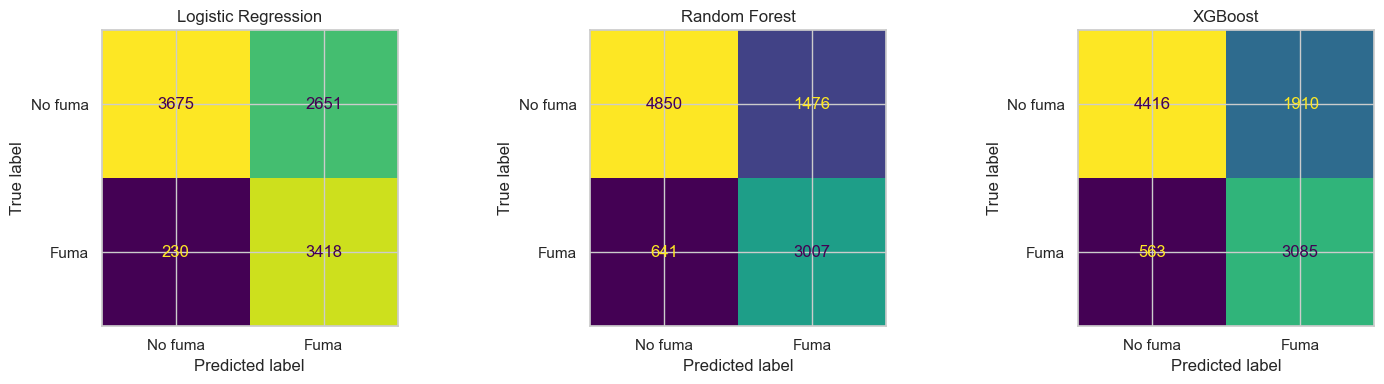

In [26]:
mostrar_confusion(resultados_base, y_test)


### sin balance

In [27]:
modelos_base = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=SEED)),
    ("Random Forest",       RandomForestClassifier(n_estimators=100,  random_state=SEED)),
    ("XGBoost",             XGBClassifier(n_estimators=100, 
                                          scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
                                          random_state=SEED, eval_metric="logloss", verbosity=0)),
]

In [28]:
resultados_base = []

for nombre, modelo in modelos_base:
    r = evaluar(nombre, modelo, X_train, y_train, X_test, y_test)
    resultados_base.append(r)


In [29]:
df_base = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados_base])
df_base.set_index("Modelo")


,F1_fumador,ROC-AUC,Accuracy,Precision_fumador,Recall_fumador
Modelo,,,,,
Logistic Regression,0.6706,0.8259,0.7463,0.6386,0.7059
Random Forest,0.7171,0.8772,0.7889,0.7031,0.7316
XGBoost,0.7139,0.8443,0.7521,0.6176,0.8457


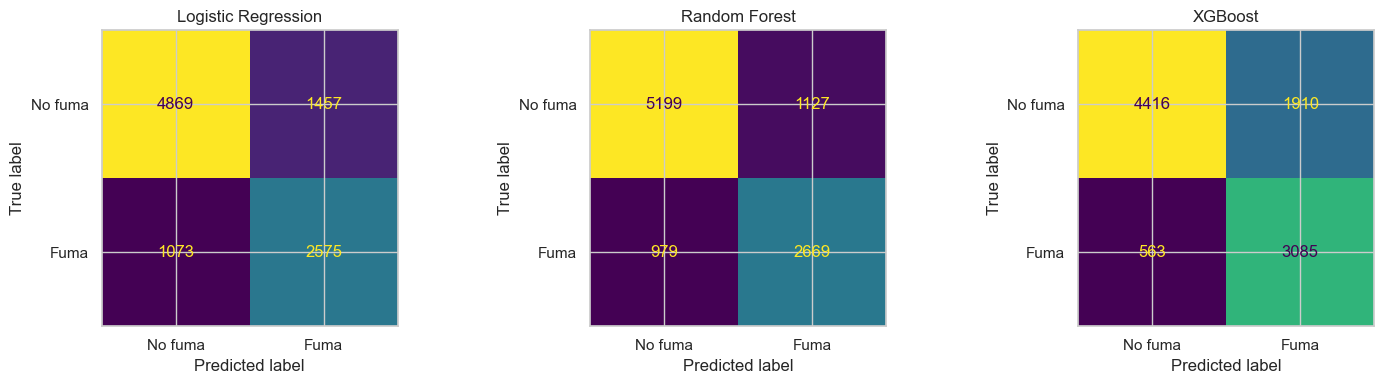

In [30]:
mostrar_confusion(resultados_base, y_test)
